# Langchain - Core components

<div class="alert alert-block alert-info">

Resources:

- <a href="https://docs.langchain.com/oss/python/langchain/overview">LangChain Docs</a>
- <a href="https://www.youtube.com/watch?v=vzJOAnwIokM">Krish Naik - Updated Langchain Crash Course</a>
- <a href="https://www.youtube.com/watch?v=J7j5tCB_y4w">NeuralNine - LangChain Full Crash Course</a>

</div>

In [ ]:
# Load libraries.
import os
from dotenv import load_dotenv
from IPython.display import display
from pprint import pprint

# Load environment variables from .env file.
load_dotenv()

## 1. Agents

Agents combine language models with tools to create systems that can reason about tasks, decide which tools to use, and iteratively work towards solutions.

`create_agent` provides a production-ready agent implementation.

An LLM Agent runs tools in a loop to achieve a goal. An agent runs until a stop condition is met - i.e., when the model emits a final output or an iteration limit is reached.

<div>
<img src="../../docs/i-tutorials/i-lc-agents.png" width="600"/>
</div>

<div class="alert alert-block alert-info">

ℹ️ `create_agent` builds a graph-based agent runtime using <a href="https://docs.langchain.com/oss/python/langgraph/overview">LangGraph</a>. A graph consists of `nodes` (steps) and `edges` (connections) that define how your agent processes information. The agent moves through this graph, executing nodes like the _model node_ (which calls the model), the _tools node_ (which executes tools), or _middleware_.

</div>

### 1.1. Core components

#### 1.1.1. Model

The model is the reasoning engine of your agent. It can be specified in multiple ways, supporting both static and dynamic model selection.

<u>_Static model:_</u>

Static models are configured once when creating the agent and remain unchanged throughout execution. This is the most common and straightforward approach.

To initialize a static model from a model identifier string.

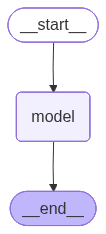

In [ ]:
from langchain.agents import create_agent

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Create the agent instance with Groq model.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile", 
    tools=[],
    system_prompt="You are a helpful assistant."
)
display(agent)

For more control over the model configuration, initialize a model instance directly using the provider package. In this example, we use `ChatNVIDIA`.

Model instances give you complete control over configuration. Use them when you need to set specific parameters like `temperature`, `max_tokens/max_completion_tokens`, `timeouts`, `base_url`, and other provider-specific settings.

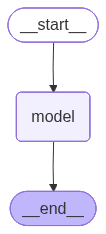

In [ ]:
from langchain.agents import create_agent
from langchain_nvidia_ai_endpoints import ChatNVIDIA

os.environ["NVIDIA_API_KEY"] = os.getenv("NVIDIA_API_KEY")

# Create the agent instance with NVIDIA model.
model = ChatNVIDIA(
    model="meta/llama-3.1-8b-instruct",
    temperature=0.1,
    max_completion_tokens=1000,
    timeout=30
    # ... (other params)
)

"""
ChatNVIDIA.get_available_models()
model.get_available_models()
"""

# Create the agent with the NVIDIA model and no tools.
agent = create_agent(model, tools=[])
display(agent)

<u>_Dynamic model:_</u>

Dynamic models are selected at runtime based on the current state and context. This enables sophisticated routing logic and cost optimization.

To use a dynamic model, create middleware using the `@wrap_model_call` decorator that modifies the model in the request.

In [30]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

# Define two models for dynamic selection.
basic_model = ChatNVIDIA(model="meta/llama-3.1-8b-instruct")
advanced_model = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")

# Middleware to select model based on conversation length.
@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    """Choose model based on conversation complexity."""
    message_count = len(request.state["messages"])

    if message_count > 10:
        # Use an advanced model for longer conversations
        model = advanced_model
    else:
        model = basic_model

    return handler(request.override(model=model))

# Create the agent with the middleware for dynamic model selection.
agent = create_agent(
    model=basic_model,  # default model
    tools=[],
    middleware=[dynamic_model_selection]
)

#### 1.1.2. Tools

Tools give agents the ability to take actions. Agents go beyond simple model-only tool binding by facilitating:
- Multiple tool calls in sequence (triggered by a single prompt)
- Parallel tool calls when appropriate
- Dynamic tool selection based on previous results
- Tool retry logic and error handling
- State persistence across tool calls

<u>_Static tools:_</u>

Static tools are defined when creating the agent and remain unchanged throughout execution. This is the most common and straightforward approach.

To define an agent with static tools, pass a list of the tools to the agent.

If an empty tool list is provided, the agent will consist of a single LLM node without tool-calling capabilities.

<div class="alert alert-block alert-info">

Tools can be specified as plain Python functions or coroutines.

The tool decorator can be used to customize tool names, descriptions, argument schemas, and other properties.

</div>

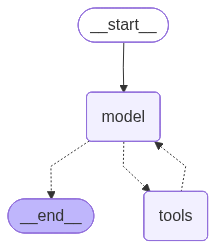

In [31]:
from langchain.tools import tool
from langchain.agents import create_agent

# Define some example tools.
@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def get_weather(location: str) -> str:
    """Get weather information for a location."""
    return f"Weather in {location}: Sunny, 72°F"

# Create the agent with the NVIDIA model and tools.
agent = create_agent(model, tools=[search, get_weather])
display(agent)

<u>_Dynamic tools:_</u>

With dynamic tools, the set of tools available to the agent is modified at runtime rather than defined all upfront. Not every tool is appropriate for every situation. Too many tools may overwhelm the model (overload context) and increase errors; too few limit capabilities. Dynamic tool selection enables adapting the available toolset based on authentication state, user permissions, feature flags, or conversation stage.

There are two approaches depending on whether tools are known ahead of time:
- [_Filtering pre-registered tools_](https://docs.langchain.com/oss/python/langchain/agents#runtime-tool-registration) - This approach is best when:
    - All possible tools are known at compile/startup time
    - You want to filter based on permissions, feature flags, or conversation state
    - Tools are static but their availability is dynamic
- [_Filtering pre-registered tools_](https://docs.langchain.com/oss/python/langchain/agents#filtering-pre-registered-tools) - This approach is best when:
    - Tools are discovered at runtime (e.g., from an MCP server)
    - Tools are generated dynamically based on user data or configuration
    - You’re integrating with external tool registries

<u>_Tool error handling:_</u>

To customize how tool errors are handled, use the `@wrap_tool_call` decorator to create middleware.

In [32]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain.messages import ToolMessage

@wrap_tool_call
def handle_tool_errors(request, handler):
    """Handle tool execution errors with custom messages."""
    try:
        return handler(request)
    except Exception as e:
        # Return a custom error message to the model
        return ToolMessage(
            content=f"Tool error: Please check your input and try again. ({str(e)})",
            tool_call_id=request.tool_call["id"]
        )

agent = create_agent(
    model="gpt-4.1",
    tools=[search, get_weather],
    middleware=[handle_tool_errors]
)

The agent will return a `ToolMessage` with the custom error message, when a tool fails:

_`Example:`_

- 
    ```python
    [
        ...
        ToolMessage(
            content="Tool error: Please check your input and try again. (division by zero)",
            tool_call_id="..."
        ),
        ...
    ]
```

<u>_Tool use in the `ReAct` loop:_</u>

Agents follow the `ReAct` (`“Reasoning + Acting”`) pattern, alternating between brief reasoning steps with targeted tool calls and feeding the resulting observations into subsequent decisions until they can deliver a final answer.

Check example of `ReAct` loop [here](https://docs.langchain.com/oss/python/langchain/agents#example-of-react-loop).

#### 1.1.3. System prompt

You can shape how your agent approaches tasks by providing a prompt. The `system_prompt` parameter can be provided as a string.

When __no__ `system_prompt` is provided, the agent will infer its task from the messages directly.

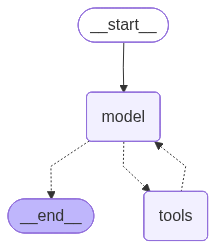

In [ ]:
# Create the agent with NVIDIA model, tools, and a system prompt.
agent = create_agent(
    model=model,
    tools=[search, get_weather],
    system_prompt="You are a helpful assistant. Be concise and accurate."
)
display(agent)

The `system_prompt` parameter accepts either a `str` or a `SystemMessage`. Using a `SystemMessage` gives you more control over the prompt structure, which is useful for provider-specific features like Anthropic’s prompt caching.

The `cache_control` field with `{"type": "ephemeral"}` tells Anthropic to cache that content block, reducing latency and costs for repeated requests that use the same system prompt.

In [ ]:
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage

# Create an agent with a system prompt that includes the contents of 'Pride and Prejudice'.
literary_agent = create_agent(
    # model="anthropic:claude-sonnet-4-5",
    model="nvidia:meta/llama-3.1-8b-instruct",
    system_prompt=SystemMessage(
        content=[
            {
                "type": "text",
                "text": "You are an AI assistant tasked with analyzing literary works.",
            },
            {
                "type": "text",
                "text": "<the entire contents of 'Pride and Prejudice'>",
                "cache_control": {"type": "ephemeral"}
            }
        ]
    )
)

# Invoke the agent with a question about 'Pride and Prejudice'.
result = literary_agent.invoke(
    {"messages": [HumanMessage("Analyze the major themes in 'Pride and Prejudice'.")]}
)

print(f"Result content:\n\n{result['messages'][-1].content}")

Result content:

In 'Pride and Prejudice', Jane Austen masterfully explores several major themes that continue to resonate with readers today. Here are some of the most significant ones:

1. **Love vs. Social Status**: The novel highlights the tension between individual desire and societal expectations. Elizabeth Bennet and Mr. Darcy's love story is complicated by their differing social stations, illustrating the challenges of navigating love in a society where class and status often take precedence.

2. **Pride and Prejudice**: The novel's title reflects the two main themes of pride and prejudice. Pride, as exemplified by Mr. Darcy, is the refusal to admit one's mistakes or change one's behavior. Prejudice, as seen in Elizabeth's initial dislike of Mr. Darcy, is the tendency to form judgments based on incomplete information. Through the characters' experiences, Austen shows how these traits can lead to misunderstandings and missed opportunities.

3. **Social Class and Economic Securit

<u>_Dynamic system prompt:_</u>

For more advanced use cases where you need to modify the system prompt based on runtime context or agent state, you can use middleware.
The `@dynamic_prompt` decorator creates middleware that generates system prompts based on the model request.

_`Example:`_

- 
    ```python
    from typing import TypedDict
    from langchain.agents import create_agent
    from langchain.agents.middleware import dynamic_prompt, ModelRequest

    class Context(TypedDict):
        user_role: str

    @dynamic_prompt
    def user_role_prompt(request: ModelRequest) -> str:
        """Generate system prompt based on user role."""
        user_role = request.runtime.context.get("user_role", "user")
        base_prompt = "You are a helpful assistant."

        if user_role == "expert":
            return f"{base_prompt} Provide detailed technical responses."
        elif user_role == "beginner":
            return f"{base_prompt} Explain concepts simply and avoid jargon."

        return base_prompt

    agent = create_agent(
        model="gpt-4.1",
        tools=[web_search],
        middleware=[user_role_prompt],
        context_schema=Context
    )

    # The system prompt will be set dynamically based on context
    result = agent.invoke(
        {"messages": [{"role": "user", "content": "Explain machine learning"}]},
        context={"user_role": "expert"}
    )
    ```

#### 1.1.4. Name

Set an optional `name` for the agent. This is used as the node identifier when adding the agent as a subgraph in multi-agent systems.

_`Example:`_

- 
    ```python
    agent = create_agent(
        model,
        tools,
        name="research_assistant"
    )
    ```

<div class="alert alert-block alert-warning">

⚠️ Prefer `snake_case` for agent names (e.g., `research_assistant` instead of `Research Assistant`). Some model providers reject names containing spaces or special characters with errors. Using alphanumeric characters, underscores, and hyphens only ensures compatibility across all providers. The same applies to tool names.

</div>

### 1.2. Invocation

You can invoke an agent by passing an update to its `State`. All agents include a sequence of messages in their state; to invoke the agent, pass a new message.

_`Example:`_

- 
    ```python
    result = agent.invoke(
        {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
    )
    ```

For streaming steps and / or tokens from the agent, refer to the streaming guide.
Otherwise, the agent follows the LangGraph Graph API and supports all associated methods, such as `stream` and `invoke`.

### 1.3. Advanced concepts

#### 1.3.1. Structured output

In some situations, you may want the agent to return an output in a specific format. LangChain provides strategies for structured output via the `response_format` parameter.

<u>_ToolStrategy:_</u>

`ToolStrategy` uses artificial tool calling to generate structured output. This works with any model that supports tool calling. `ToolStrategy` should be used when provider-native structured output (via `ProviderStrategy`) is not available or reliable.

_`Example:`_

- 
    ```python
    from pydantic import BaseModel
    from langchain.agents import create_agent
    from langchain.agents.structured_output import ToolStrategy

    class ContactInfo(BaseModel):
        name: str
        email: str
        phone: str

    agent = create_agent(
        model="gpt-4.1-mini",
        tools=[search_tool],
        response_format=ToolStrategy(ContactInfo)
    )

    result = agent.invoke({
        "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
    })

    result["structured_response"]
    # ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')
    ```


<u>_ProviderStrategy:_</u>

`ProviderStrategy` uses the model provider’s native structured output generation. This is more reliable but only works with providers that support native structured output:

_`Example:`_

- 
    ```python
    from langchain.agents.structured_output import ProviderStrategy

    agent = create_agent(
        model="gpt-4.1",
        response_format=ProviderStrategy(ContactInfo)
    )
    ```

#### 1.3.2. Memory

Agents maintain conversation history automatically through the message state. You can also configure the agent to use a custom state schema to remember additional information during the conversation.

Information stored in the state can be thought of as the short-term memory of the agent:

Custom state schemas must extend `AgentState` as a `TypedDict`.

There are two ways to define custom state:
- Via _middleware_ (preferred)
- Via `state_schema` on `create_agent`

<u>_Defining state via middleware:_</u>

Use middleware to define custom state when your custom state needs to be accessed by specific middleware hooks and tools attached to said middleware.

_`Example:`_

- 
    ```python
    from langchain.agents import AgentState
    from langchain.agents.middleware import AgentMiddleware
    from typing import Any

    class CustomState(AgentState):
        user_preferences: dict

    class CustomMiddleware(AgentMiddleware):
        state_schema = CustomState
        tools = [tool1, tool2]

        def before_model(self, state: CustomState, runtime) -> dict[str, Any] | None:
            ...

    agent = create_agent(
        model,
        tools=tools,
        middleware=[CustomMiddleware()]
    )

    # The agent can now track additional state beyond messages
    result = agent.invoke({
        "messages": [{"role": "user", "content": "I prefer technical explanations"}],
        "user_preferences": {"style": "technical", "verbosity": "detailed"},
    })
    ```

<u>_Defining state via `state_schema`_</u>

Use the `state_schema` parameter as a shortcut to define custom state that is only used in tools.

_`Example:`_

- 
    ```python
    from langchain.agents import AgentState

    class CustomState(AgentState):
        user_preferences: dict

    agent = create_agent(
        model,
        tools=[tool1, tool2],
        state_schema=CustomState
    )
    # The agent can now track additional state beyond messages
    result = agent.invoke({
        "messages": [{"role": "user", "content": "I prefer technical explanations"}],
        "user_preferences": {"style": "technical", "verbosity": "detailed"},
    })
    ```

<div class="alert alert-block alert-info">

ℹ️ 
- Defining custom state via middleware is preferred over defining it via `state_schema` on `create_agent` because it allows you to keep state extensions conceptually scoped to the relevant middleware and tools.

- `state_schema` is still supported for backwards compatibility on `create_agent`.

</div>

#### 1.3.3. Streaming

We’ve seen how the agent can be called with `invoke` to get a final response. If the agent executes multiple steps, this may take a while. To show intermediate progress, we can stream back messages as they occur.

_`Example:`_

- 
    ```python
    from langchain.messages import AIMessage, HumanMessage

    for chunk in agent.stream({
        "messages": [{"role": "user", "content": "Search for AI news and summarize the findings"}]
    }, stream_mode="values"):
        # Each chunk contains the full state at that point
        latest_message = chunk["messages"][-1]
        if latest_message.content:
            if isinstance(latest_message, HumanMessage):
                print(f"User: {latest_message.content}")
            elif isinstance(latest_message, AIMessage):
                print(f"Agent: {latest_message.content}")
        elif latest_message.tool_calls:
            print(f"Calling tools: {[tc['name'] for tc in latest_message.tool_calls]}")
    ```

#### 1.3.4. Middleware

Middleware provides powerful extensibility for customizing agent behavior at different stages of execution. You can use middleware to:
- Process state before the model is called (e.g., message trimming, context injection)
- Modify or validate the model’s response (e.g., guardrails, content filtering)
- Handle tool execution errors with custom logic
- Implement dynamic model selection based on state or context
- Add custom logging, monitoring, or analytics

Middleware integrates seamlessly into the agent’s execution, allowing you to intercept and modify data flow at key points without changing the core agent logic.

## 2. Models

LLMs are powerful AI tools that can interpret and generate text like humans. They’re versatile enough to write content, translate languages, summarize, and answer questions without needing specialized training for each task.

In addition to text generation, many models support:
- __🛠️ Tool calling__ - calling external tools (like databases queries or API calls) and use results in their responses.
- __⊞ Structured output__ - where the model’s response is constrained to follow a defined format.
- __🏞️ Multimodality__ - process and return data other than text, such as images, audio, and video.
- __🧠 Reasoning__ - models perform multi-step reasoning to arrive at a conclusion.

`Models` are the reasoning engine of agents. They drive the agent’s decision-making process, determining which tools to call, how to interpret results, and when to provide a final answer.

### 2.1. Basic usage

Models can be utilized in two ways:
- __With agents__ - Models can be dynamically specified when creating an agent.
- __Standalone__ - Models can be called directly (outside of the agent loop) for tasks like text generation, classification, or extraction without the need for an agent framework.

The same model interface works in both contexts, which gives you the flexibility to start simple and scale up to more complex agent-based workflows as needed.

#### 2.1.1. Initialize a model 

The easiest way to get started with a standalone model in LangChain is to use `init_chat_model` to initialize one from a chat model provider of your choice.

```bash
uv add "langchain[google-genai]"
```

_`Example: init_chat_model`_

In [ ]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model = init_chat_model("google_genai:gemini-2.5-flash-lite")
response = model.invoke("What is an LLM?")

pprint(response)
print(f"\n{'='*100}\n")
print(f"Response content:\n\n{response.content}")

AIMessage(content='**LLM stands for Large Language Model.**\n\nIn simple terms, an LLM is a type of **artificial intelligence (AI)** that is designed to **understand, generate, and process human language.**\n\nHere\'s a breakdown of what that means:\n\n*   **Large:** This refers to the immense amount of data the model is trained on. This data typically includes vast collections of text and code from the internet, books, articles, and other sources. The sheer scale of this training data is what allows LLMs to learn complex patterns, grammar, facts, and different writing styles.\n\n*   **Language:** This is the core focus. LLMs are specialized in working with human language in all its forms – written text, and often, through their underlying architecture, they can even process and generate spoken language (though the output is usually text).\n\n*   **Model:** In the context of AI, a "model" is a mathematical representation of the patterns and relationships learned from the training data.

_`Example: Model Class`_

- 
    ```python
    import os
    from langchain_google_genai import ChatGoogleGenerativeAI

    os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

    model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
    response = model.invoke("What is an LLM?")

    pprint(response)
    print(f"\n{'='*100}\n")
    print(f"Response content:\n\n{response.content}")
    ```

#### 2.1.2. Supported models

LangChain supports all major model providers, including OpenAI, Anthropic, Google, Azure, AWS Bedrock, and more. Each provider offers a variety of models with different capabilities. For a full list of supported models in LangChain, see the [integrations page](https://docs.langchain.com/oss/python/integrations/providers/overview).

#### 2.1.3. Key methods

- `invoke`: The model takes messages as input and outputs messages after generating a complete response.
- `stream`: Invoke the model, but stream the output as it is generated in real-time.
- `batch`: Send multiple requests to a model in a batch for more efficient processing.

### 2.2. Parameters

A chat model takes parameters that can be used to configure its behavior. The full set of supported parameters varies by model and provider, but standard ones include:
​
- `model` (string _required_):

    The name or identifier of the specific model you want to use with a provider. You can also specify both the model and its provider in a single argument using the ’:’ format, for example, ‘openai:o1’.
​
- `api_key` (string):

    The key required for authenticating with the model’s provider. This is usually issued when you sign up for access to the model. Often accessed by setting an environment variable.
​
- `temperature` (number):

    Controls the randomness of the model’s output. A higher number makes responses more creative; lower ones make them more deterministic.
​
- `max_tokens` (number):

    Limits the total number of tokens in the response, effectively controlling how long the output can be.
​
- `timeout` (number):

    The maximum time (in seconds) to wait for a response from the model before canceling the request.
​
- `max_retries` (number `default:"6"`):

    The maximum number of attempts the system will make to resend a request if it fails due to issues like network timeouts or rate limits. Retries use exponential backoff with jitter. Network errors, rate limits (429), and server errors (5xx) are retried automatically. Client errors such as 401 (unauthorized) or 404 are not retried. For long-running agent tasks on unreliable networks, consider increasing this to 10–15.

Using `init_chat_model`, pass these parameters as inline `**kwargs`.

_`Example:`_

- 
    ```python
    model = init_chat_model(
        "claude-sonnet-4-6",
        # Kwargs passed to the model:
        temperature=0.7,
        timeout=30,
        max_tokens=1000,
        max_retries=6,  # Default; increase for unreliable networks
    )
    ```

### 2.3. Invocation

A chat model must be invoked to generate an output. There are three primary invocation methods, each suited to different use cases.

#### 2.3.1. Invoke

The most straightforward way to call a model is to use `invoke()` with a single message or a list of messages.

_`Example: Single message`_

- 
    ```python
    response = model.invoke("Why do parrots have colorful feathers?")
    print(response)
    ```

A list of messages can be provided to a chat model to represent conversation history. Each message has a role that models use to indicate who sent the message in the conversation.

_`Example: Dictionary format`_

- 
    ```python
    conversation = [
        {"role": "system", "content": "You are a helpful assistant that translates English to French."},
        {"role": "user", "content": "Translate: I love programming."},
        {"role": "assistant", "content": "J'adore la programmation."},
        {"role": "user", "content": "Translate: I love building applications."}
    ]

    response = model.invoke(conversation)
    print(response)  # AIMessage("J'adore créer des applications.")
    ```

_`Example: Message object`_

- 
    ```python
    from langchain.messages import HumanMessage, AIMessage, SystemMessage

    conversation = [
        SystemMessage("You are a helpful assistant that translates English to French."),
        HumanMessage("Translate: I love programming."),
        AIMessage("J'adore la programmation."),
        HumanMessage("Translate: I love building applications.")
    ]

    response = model.invoke(conversation)
    print(response)  # AIMessage("J'adore créer des applications.")
    ```

#### 2.3.2. Stream

#### 2.3.3. Batch

### 2.4. Tool calling

### 2.5. Structured output

Model profiles




In [ ]:
# Define a simple tool/function to get the weather for a city.
'''
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    response = requests.get(f"https://wttr.in/{city}?format=j1")
    return response.json()
'''
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    response = f"The current weather in {city} is sunny with a temperature of 25°C."
    return response

# Create an agent with the weather tool.
agent_with_tool = create_agent(
    model=model_llm,
    tools=[get_weather],
    system_prompt="You are a helpful weather assistant, who always cracks jokes and is humrous while remaining helpful."
)
display(agent_with_tool)

In [ ]:
# Run the agent with a query.
response = agent_with_tool.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What is the current weather in New York?"
        }
    ]
})

print(response)
print(f"\n{'=' * 100}\n")
print(response['messages'][-1].content)

In [ ]:
pprint(response['messages'])
print(f"\n{'=' * 100}\n")
print(response['messages'])

In [ ]:
# Alternate way to run the agent with a query.
response = agent_with_tool.invoke(
    {
        "messages": "What is the current weather in New York?"
    }
)
print(response['messages'][-1].content)

In [ ]:
from langchain.chat_models import init_chat_model

# Initialize different chat models from various providers.
"""
model = init_chat_model(model="nvidia:meta/llama-3.1-405b-instruct")
model = init_chat_model(model="groq:llama-3.3-70b-versatile")
"""
# model = init_chat_model(model="google_genai:gemini-2.5-flash-lite")
model = init_chat_model(model="google_genai:gemini-2.5-flash")

# Invoke the models with a simple query.
query = "What is the capital of France?"
response = model.invoke(query)

# Print the responses.
print(f"Response:    {response.content}")

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Directly initialize and invoke the models.
"""
from langchain_groq import ChatGroq

model = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")
model = ChatGroq (model="llama-3.3-70b-versatile")
"""
# model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# Invoke the models with a simple query.
query = "What is the capital of Australia?"
response = model.invoke(query)

# Print the responses.
print(f"Response:    {response.content}")

#### 2.1.2. Stream

Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses.

Calling `stream()` returns an iterator that yields output chunks as they are produced. 

In [ ]:
model = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")

# Model response with streaming response.
query = "Tell me a joke."
model.invoke(query)
# model.stream(query)

# basic text streaming.
for chunk in model.stream(query):
    print(chunk.content, end="|", flush=True)

print(f"\n{'='*100}\n")

# Stream tool calls, reasoning and other contents.
for chunk in model.stream(query):
    for block in chunk.content_blocks:
        if block["type"] == "reasoning" and (reasoning := block.get("reasoning")):
            print(f"Reasoning: {reasoning}")
        elif block["type"] == "tool_call_chunk":
            print(f"Tool call chunk: {block}")
        elif block["type"] == "text":
            print(block["text"])
        else:
            pass

As opposed to `invoke()`, which returns a single `AIMessage` after the model has finished generating its full response, `stream()` returns multiple `AIMessageChunk` objects, each containing a portion of the output text. Importantly, each chunk in a stream is designed to be gathered into a full message via summation:

```python
full = None  # None | AIMessageChunk
for chunk in model.stream("What color is the sky?"):
    full = chunk if full is None else full + chunk
    print(full.text)

print(f"\n{'='*100}\n")
print(full.content_blocks)
```

#### 2.1.3. Batch

Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel.

In [ ]:
# Model response with batch queries.
queries = [
    "What is large language model?", 
    "What is AI?", 
    "What is the meaning of life?"
]
responses = model.batch(queries)
for i, response in enumerate(responses):
    print(f"Query: {queries[i]}\nResponse: {response.content}\n\n{'=' * 100}\n")

By default, `batch()` will only return the final output for the entire batch. If you want to receive the output for each individual input as it finishes generating, you can stream results with `batch_as_completed()`.

- 
    ```python
    responses = model.batch_as_completed(queries)
    for i, response in enumerate(responses):
        print(f"Query: {queries[i]}\nResponse: {response}\n\n{'=' * 100}\n")
    ```

When processing a large number of inputs using `batch()` or `batch_as_completed()`, you may want to control the maximum number of parallel calls. This can be done by setting the `max_concurrency` attribute in the `RunnableConfig` dictionary.

- 
    ```python
    responses = model.batch(
        inputs=queries,
        config={
            'max_concurrency':2,  # limit to 2 parallel calls
        }
    )
    for i, response in enumerate(responses):
        print(f"Query: {query[i]}\nResponse: {response.content}\n\n{'=' * 100}\n")
    ```

### 2.2. Tool calling

Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:

- A `schema`, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
- A `function` or coroutine to execute.

Here’s the basic tool calling flow between a user and a model:

<div>
<img src="../../docs/i-tutorials/i-lc-models-tool-calling.png" width="800"/>
</div>

To make tools that you have defined available for use by a model, you must bind them using `bind_tools`. In subsequent invocations, the model can choose to call any of the bound tools as needed.

Some model providers offer built-in tools that can be enabled via model or invocation parameters (e.g. `ChatOpenAI`, `ChatAnthropic`).

Either have docstring in the function definition or use the @tool decorator to add description and metadata to the tool.

_`Example:`_

- 
    ```python
    @tool(
        'get_weather', 
        description="Get the current weather for a given city.", 
        return_direct=False
    )
    def get_weather(city: str) -> str:
        '''Get the current weather for a given city.'''
        response = requests.get(f"https://wttr.in/{city}?format=j1")
        return response.json()
    ```

In [ ]:
from langchain.tools import tool

# Define a tool/function to get the weather for a city.
@tool
def get_weather(location: str) -> str:
    """Get the weather at a location."""
    return f"It's sunny in {location}."

# Bind the tool to the model and invoke it with a query that requires the tool.
model_with_tools = model.bind_tools(tools=[get_weather])

response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)
print(f"\n{'=' * 100}\n")

for tool_call in response.tool_calls:
    # View tool calls made by the model.
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

In [ ]:
pprint(response)
print(f"\n{'=' * 100}\n")
pprint(response['messages'])
print(f"\n{'=' * 100}\n")
print(response['messages'][1].tool_calls)
print(f"\n{'=' * 100}\n")
print(response['messages'][-1].content)

Below, are some common ways to use tool calling.

- __Tool execution loop__

    When a model returns tool calls, you need to execute the tools and pass the results back to the model. This creates a conversation loop where the model can use tool results to generate its final response. LangChain includes agent abstractions that handle this orchestration for you.

    Here’s a simple example of how to do this:

    - 
        ```python
        # Bind (potentially multiple) tools to the model.
        model_with_tools = model.bind_tools([get_weather])

        # Step 1: Model generates tool calls.
        messages = [{"role": "user", "content": "What's the weather in Boston?"}]
        ai_msg = model_with_tools.invoke(messages)
        messages.append(ai_msg)

        # Step 2: Execute tools and collect results
        for tool_call in ai_msg.tool_calls:
            # Execute the tool with the generated arguments
            tool_result = get_weather.invoke(tool_call)
            messages.append(tool_result)

        # Step 3: Pass results back to model for final response.
        final_response = model_with_tools.invoke(messages)
        print(final_response.text)
        # "The current weather in Boston is 72°F and sunny."

        print(f"\n{'='*100}\n")
        print(messages)
        ```

- __Forcing tool calls__

    By default, the model has the freedom to choose which bound tool to use based on the user’s input. However, you might want to force choosing a tool, ensuring the model uses either a particular tool or any tool from a given list:

    - 
        ```python
        # Force use of any tool.
        model_with_tools = model.bind_tools([tool_1], tool_choice="any")

        # Force use of specific tool.
        model_with_tools = model.bind_tools([tool_1], tool_choice="tool_1")
        ```

- __Parallel tool calls__

    Many models support calling multiple tools in parallel when appropriate. This allows the model to gather information from different sources simultaneously.

    - 
        ```python
        model_with_tools = model.bind_tools([get_weather])

        response = model_with_tools.invoke(
            "What's the weather in Boston and Tokyo?"
        )

        # The model may generate multiple tool calls.
        print(response.tool_calls)
        
        # Execute all tools (can be done in parallel with async).
        results = []
        for tool_call in response.tool_calls:
            if tool_call['name'] == 'get_weather':
                result = get_weather.invoke(tool_call)
            ...
            results.append(result)
        ```

    Most models supporting tool calling enable parallel tool calls by default. Some (including `OpenAI` and `Anthropic`) allow you to disable this feature. To do this, set `parallel_tool_calls=False`.
    
    - 
        ```python
        model.bind_tools([get_weather], parallel_tool_calls=False)
        ```

- __Streaming tool calls__

    When streaming responses, tool calls are progressively built through `ToolCallChunk`. This allows you to see tool calls as they’re being generated rather than waiting for the complete response.

    - 
        ```python
        for chunk in model_with_tools.stream(
            "What's the weather in Boston and Tokyo?"
        ):
            # Tool call chunks arrive progressively
            for tool_chunk in chunk.tool_call_chunks:
                if name := tool_chunk.get("name"):
                    print(f"Tool: {name}")
                if id_ := tool_chunk.get("id"):
                    print(f"ID: {id_}")
                if args := tool_chunk.get("args"):
                    print(f"Args: {args}")
        ```

    You can accumulate chunks to build complete tool calls.
    
    - 
        ```python
        # Accumulate tool calls
        gathered = None
        for chunk in model_with_tools.stream("What's the weather in Boston?"):
            gathered = chunk if gathered is None else gathered + chunk
            print(gathered.tool_calls)
        ```

### 2.2. Structured output

TBC

## 3. Messages

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the content and metadata needed to represent the state of a conversation when interacting with an LLM.

Messages are objects that contain:

- __👨‍💼Role__ - Identifies the message type (e.g. `system`, `user`)
- __🗂️Content__ - Represents the actual content of the message (like text, images, audio, documents, etc.)
- __🏷️Metadata__ - Optional fields such as response information, message IDs, and token usage

LangChain provides a standard message type that works across all model providers, ensuring consistent behavior regardless of the model being called.

### 3.1. Basic usage

The simplest way to use messages is to create message objects and pass them to a model when invoking.

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, SystemMessage

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

system_msg = SystemMessage("You are a helpful assistant.")
human_msg = HumanMessage("Hello, how are you?")

# Use with chat models.
messages = [system_msg, human_msg]
response = model.invoke(messages)  # returns AIMessage
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

#### 3.1.1. Text prompts

Text prompts are strings - ideal for straightforward generation tasks where you don’t need to retain conversation history.

Use text prompts when:

- You have a single, standalone request
- You don’t need conversation history
- You want minimal code complexity

In [ ]:
response = model.invoke("Write a haiku about spring")
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

#### 3.1.2. Message prompts

You can also pass in a list of messages to the model by providing a list of message objects.

Use message prompts when:

- Managing multi-turn conversations
- Working with multimodal content (images, audio, files)
- Including system instructions

In [ ]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a haiku about spring"),
    AIMessage("Cherry blossoms bloom...")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

#### 3.1.3. Dictionary format

You can also specify messages directly in `OpenAI` chat completions format.

In [ ]:
messages = [
    {"role": "system", "content": "You are a poetry expert"},
    {"role": "user", "content": "Write a haiku about spring"},
    {"role": "assistant", "content": "Cherry blossoms bloom..."}
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

### 3.2. Message types

- __⚙System message__ - Tells the model how to behave and provide context for interactions
- __👨‍💼Human message__ - Represents user input and interactions with the model
- __🤖AI message__ - Responses generated by the model, including text content, tool calls, and metadata
- __🔧Tool message__ - Represents the outputs of tool calls

#### 3.2.1. System message

A `SystemMessage` represent an initial set of instructions that primes the model’s behavior. You can use a system message to set the tone, define the model’s role, and establish guidelines for responses.

In [ ]:
# Basic instructions.
system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

In [ ]:
# Detailed persona.
from langchain.messages import SystemMessage, HumanMessage

system_msg = SystemMessage("""
You are a senior Python developer with expertise in web frameworks.
Always provide code examples and explain your reasoning.
Be concise but thorough in your explanations.
""")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

#### 3.2.2. Human message

A `HumanMessage` represents user input and interactions. They can contain text, images, audio, files, and any other amount of multimodal content.

_Text content_

In [ ]:
# Message object.
response = model.invoke([
  HumanMessage("What is machine learning?")
])

print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

In [ ]:
# Using a string as a shortcut for a single HumanMessage.
response = model.invoke("What is machine learning?")

print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

_Message metadata_

```python
# Message object with metadata.
human_msg = HumanMessage(
    content="Hello!",
    name="alice",  # optional: identify different users
    id="msg_123",  # optional: unique identifier for tracing
)
```

#### 3.2.3. AI message

An `AIMessage` represents the output of a model invocation. They can include multimodal data, tool calls, and provider-specific metadata that you can later access.

`AIMessage` objects are returned by the model when calling it, which contains all of the associated metadata in the response.

In [ ]:
response = model.invoke("Explain AI")
print(f"Response type: {type(response)}")

Providers weigh/contextualize types of messages differently, which means it is sometimes helpful to manually create a new `AIMessage` object and insert it into the message history as if it came from the model.

In [ ]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage

# Create an AI message manually (e.g., for conversation history).
ai_msg = AIMessage("I'd be happy to help you with that question!")

# Add to conversation history.
messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg,  # insert as if it came from the model
    HumanMessage("Great! What's 2+2?")
]

response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")
print(f"\n{'=' * 100}\n")
print(f"Usage metadata:\n{response.usage_metadata}")

_`Tool calls`_

When models make tool calls, they’re included in the `AIMessage`.

Other structured data, such as `reasoning` or `citations`, can also appear in message content.

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

def get_weather(location: str) -> str:
    """Get the weather at a location."""
    ...

model_with_tools = model.bind_tools([get_weather])
response = model_with_tools.invoke("What's the weather in Paris?")

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")
    print(f"ID: {tool_call['id']}")

_`Token usage`_

An `AIMessage` can hold token counts and other usage metadata in its usage_metadata field.

In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

response = model.invoke("Hello!")
print(f"Response usage metadata:\n{response.usage_metadata}")

_`Streaming and chunks`_

During streaming, you’ll receive `AIMessageChunk` objects that can be combined into a full message object.

In [ ]:
chunks = []
full_message = None
for chunk in model.stream("Hi"):
    chunks.append(chunk)
    print(chunk.text)
    full_message = chunk if full_message is None else full_message + chunk

print(f"\n{'=' * 100}\n")
print(f"Full message:\n{full_message}")

#### 3.2.4. Tool message

For models that support tool calling, AI messages can contain tool calls. Tool messages are used to pass the results of a single tool execution back to the model.

Tools can generate `ToolMessage` objects directly. Below, is a simple example.

In [ ]:
from langchain.messages import AIMessage
from langchain.messages import ToolMessage

# After a model makes a tool call
# (Here, we demonstrate manually creating the messages for brevity)
ai_message = AIMessage(
    content=[],
    tool_calls=[{
        "name": "get_weather",
        "args": {"location": "San Francisco"},
        "id": "call_123"
    }]
)

# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123"  # Must match the call ID
)

# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message,  # Model's tool call
    tool_message,  # Tool execution result
]
response = model.invoke(messages)  # Model processes the result
print(f"Model response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Model response content:\n{response.content}")

<div class="alert alert-block alert-info">

### 3.3. Message content

Check <a href="https://docs.langchain.com/oss/python/langchain/messages#message-content">here</a> for more details.

#### 3.3.1. Standard content blocks
#### 3.3.2. Multimodal
#### 3.3.3. Content block reference

</div>

## 4. Tools

Tools extend what agents can do—letting them fetch real-time data, execute code, query external databases, and take actions in the world.

Under the hood, tools are callable functions with well-defined inputs and outputs that get passed to a chat model. The model decides when to invoke a tool based on the conversation context, and what input arguments to provide.

### 4.1. Create tools

#### 4.1.1. Basic tool definition

The simplest way to create a tool is with the `@tool` decorator. By default, the function’s docstring becomes the tool’s description that helps the model understand when to use it.

Type hints are __required__ as they define the tool’s input schema. The docstring should be informative and concise to help the model understand the tool’s purpose.

<div class="alert alert-block alert-warning">

Prefer `snake_case` for tool names (e.g., `web_search` instead of `Web Search`). Some model providers have issues with or reject names containing spaces or special characters with errors. Sticking to alphanumeric characters, underscores, and hyphens helps to improve compatibility across providers.

</div>

In [ ]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

# Define a tool/function to search a database.
@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    return f"Found {limit} results for '{query}'"

# Create an agent with the search tool.
agent_with_tool = init_chat_model(model="groq:llama-3.3-70b-versatile").bind_tools(tools=[search_database])
response = agent_with_tool.invoke("Search the database for customers in New York.")
print(f"Agent response:\n{response}")

print(f"\n{'=' * 100}\n")
print(f"Agent response content:\n{response.content}")

print(f"\n{'=' * 100}\n")
print(f"Tool: {response.tool_calls[0]['name']}")
print(f"Args: {response.tool_calls[0]['args']}")

<div class="alert alert-block alert-info">

__*Question: Why is `response.content` empty?*__

__Answer:__
This is expected behaviour. When you use `bind_tools()`, the model generates tool calls but doesn't execute them or produce final text content automatically.

`response.content` is empty because the model is indicating it wants to call the `search_database` tool. The actual information is in `response.tool_calls`.

To get content with an answer, you need to implement the `tool execution loop`.

Alternatively, use LangChain's `create_agent()` which handles the tool execution loop automatically (as shown in your earlier agent examples).

</div>

#### 4.1.2. Customize tool properties

_Custome tool name_

By default, the tool name comes from the function name. Override it when you need something more descriptive.

In [ ]:
@tool("web_search")  # Custom name
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

print(f"Tool name: {search.name}")  # web_search

_Custom tool description_

Override the auto-generated tool description for clearer model guidance.

- 
    ```python
    @tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
    def calc(expression: str) -> str:
        """Evaluate mathematical expressions."""
        return str(eval(expression))
    ```

#### 4.1.3. Advanced schema definition

Define complex inputs with Pydantic models or JSON schemas.

_`Example: Pydantic model`_

- 
    ```python
    from pydantic import BaseModel, Field
    from typing import Literal

    # Define a tool with structured input using Pydantic models.
    class WeatherInput(BaseModel):
        """Input for weather queries."""
        location: str = Field(description="City name or coordinates")
        units: Literal["celsius", "fahrenheit"] = Field(
            default="celsius",
            description="Temperature unit preference"
        )
        include_forecast: bool = Field(
            default=False,
            description="Include 5-day forecast"
        )

    # Define a tool that uses the WeatherInput schema for its arguments.
    @tool(args_schema=WeatherInput)
    def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
        """Get current weather and optional forecast."""
        temp = 22 if units == "celsius" else 72
        result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
        if include_forecast:
            result += "\nNext 5 days: Sunny"
        return result
    ```

_`Example: JSON schema`_

- 
    ```python
    # Define the same tool using a JSON schema instead of Pydantic.
    weather_schema = {
        "type": "object",
        "properties": {
            "location": {"type": "string"},
            "units": {"type": "string"},
            "include_forecast": {"type": "boolean"}
        },
        "required": ["location", "units", "include_forecast"]
    }

    # Define a tool that uses the WeatherInput schema for its arguments.
    @tool(args_schema=weather_schema)
    def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
        """Get current weather and optional forecast."""
        temp = 22 if units == "celsius" else 72
        result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
        if include_forecast:
            result += "\nNext 5 days: Sunny"
        return result
    ```

#### 4.1.4. Reserved argument names

The following parameter names are reserved and cannot be used as tool arguments. Using these names will cause runtime errors.

| Parameter name | Purpose |
|:---------------|:--------|
| __`config`__ | Reserved for passing RunnableConfig to tools internally |
| __`runtime`__ | Reserved for ToolRuntime parameter (accessing state, context, store) |

To access runtime information, use the `ToolRuntime` parameter instead of naming your own arguments `config` or `runtime`.

### 4.2. Access context

Tools are most powerful when they can access runtime information like conversation history, user data, and persistent memory. This section covers how to access and update this information from within your tools.

Tools can access runtime information through the `ToolRuntime` parameter, which provides:

| Component | Description | Use case |
|:----------|:------------|:---------|
| __State__ | Short-term memory - mutable data that exists for the current conversation (messages, counters, custom fields) | Access conversation history, track tool call counts |
| __Context__ | Immutable configuration passed at invocation time (user IDs, session info) | Personalize responses based on user identity |
| __Store__ | Long-term memory - persistent data that survives across conversations | Save user preferences, maintain knowledge base |
| __Stream Writer__ | Emit real-time updates during tool execution | Show progress for long-running operations |
| __Config__ | `RunnableConfig` for the execution | Access callbacks, tags, and metadata |
| __Tool Call ID__ | Unique identifier for the current tool invocation | Correlate tool calls for logs and model invocations |

<div>
<img src="../../docs/i-tutorials/i-lc-tools-access-context.png" width="800"/>
</div>

#### 4.2.1. Short-term memory (State)

State represents short-term memory that exists for the duration of a conversation. It includes the message history and any custom fields you define in your graph state.

<div class="alert alert-block alert-info">

ℹ️ Add `runtime: ToolRuntime` to your tool signature to access state. This parameter is automatically injected and hidden from the LLM - it won’t appear in the tool’s schema.

</div>

_Access state_

Tools can access the current conversation state using `runtime.state`.

_`Example:`_

- 
    ```python
    from langchain.tools import tool, ToolRuntime
    from langchain.messages import HumanMessage

    @tool
    def get_last_user_message(runtime: ToolRuntime) -> str:
        """Get the most recent message from the user."""
        messages = runtime.state["messages"]

        # Find the last human message
        for message in reversed(messages):
            if isinstance(message, HumanMessage):
                return message.content

        return "No user messages found"

    # Access custom state fields
    @tool
    def get_user_preference(
        pref_name: str,
        runtime: ToolRuntime
    ) -> str:
        """Get a user preference value."""
        preferences = runtime.state.get("user_preferences", {})
        return preferences.get(pref_name, "Not set")
    ```

<div class="alert alert-block alert-warning">

⚠️ The `runtime` parameter is hidden from the model. For the example above, the model only sees `pref_name` in the tool schema.

</div>

_Update state_

Use `Command` to update the agent’s state. This is useful for tools that need to update custom state fields.

_`Example:`_

- 
    ```python
    from langgraph.types import Command
    from langchain.tools import tool

    @tool
    def set_user_name(new_name: str) -> Command:
        """Set the user's name in the conversation state."""
        return Command(update={"user_name": new_name})
    ```

#### 4.2.2. Context

Context provides immutable configuration data that is passed at invocation time. Use it for user IDs, session details, or application-specific settings that shouldn’t change during a conversation.
Access context through `runtime.context`.

In [ ]:
from dataclasses import dataclass
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime

# Mock user database for demonstration purposes.
USER_DATABASE = {
    "user123": {
        "name": "Alice Johnson",
        "account_type": "Premium",
        "balance": 5000,
        "email": "alice@example.com"
    },
    "user456": {
        "name": "Bob Smith",
        "account_type": "Standard",
        "balance": 1200,
        "email": "bob@example.com"
    }
}

# Define a context schema for the agent to access user-specific information.
@dataclass
class UserContext:
    user_id: str

# Define a tool to get account information based on the user context.
@tool
def get_account_info(runtime: ToolRuntime[UserContext]) -> str:
    """Get the current user's account information."""
    user_id = runtime.context.user_id

    if user_id in USER_DATABASE:
        user = USER_DATABASE[user_id]
        return f"Account holder: {user['name']}\nType: {user['account_type']}\nBalance: ${user['balance']}"
    return "User not found"

# Create an agent with the tool and user context.
model = ChatGroq(model="llama-3.3-70b-versatile")
agent = create_agent(
    model,
    tools=[get_account_info],
    context_schema=UserContext,
    system_prompt="You are a financial assistant."
)

# Invoke the agent with a query and user context.
result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's my current balance?"}]},
    context=UserContext(user_id="user123")
)

print(f"Result:\n{result}")
# print(f"\n{'=' * 100}\n")
# print(f"Messages in the result:\n{result['messages']}")

Formatted `result` from above.

- 
    ```python
    [
        HumanMessage(
            content="What's my current balance?", 
            additional_kwargs={}, 
            response_metadata={}, 
            id='e39ed6d1-1049-4d61-9d26-ec8f6324f9b5'
        ), 
        
        AIMessage(
            content='', 
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'nypc8gd26', 
                        'function': {
                            'arguments': '{}', 
                            'name': 'get_account_info'
                        }, 
                        'type': 'function'
                    }
                ]
            }, 
            response_metadata={
                'token_usage': {
                    'completion_tokens': 9, 'prompt_tokens': 219, 'total_tokens': 228, 'completion_time': 0.017738521, 'completion_tokens_details': None, 'prompt_time': 0.040064377, 'prompt_tokens_details': None, 'queue_time': 0.041749179, 'total_time': 0.057802898
                }, 
                'model_name': 'llama-3.3-70b-versatile', 
                'system_fingerprint': 'fp_f8b414701e', 
                'service_tier': 'on_demand', 
                'finish_reason': 'tool_calls', 
                'logprobs': None, 
                'model_provider': 'groq'
            }, 
            id='lc_run--019d3926-9ac3-73c0-b771-edffb5b39e1a-0', 
            tool_calls=[
                {
                    'name': 'get_account_info', 
                    'args': {}, 
                    'id': 'nypc8gd26', 
                    'type': 'tool_call'
                }
            ], 
            invalid_tool_calls=[], 
            usage_metadata={
                'input_tokens': 219, 
                'output_tokens': 9, 
                'total_tokens': 228
            }
        ), 
        
        ToolMessage(
            content='Account holder: Alice Johnson\nType: Premium\nBalance: $5000', name='get_account_info', 
            id='56b3560b-633d-4b1f-b2f9-7e546f3d38de', 
            tool_call_id='nypc8gd26'
        ), 
        
        AIMessage(
            content='Your current balance is $5000.', 
            additional_kwargs={}, 
            response_metadata={
                'token_usage': {
                    'completion_tokens': 9, 
                    'prompt_tokens': 254, 
                    'total_tokens': 263, 
                    'completion_time': 0.035944511, 
                    'completion_tokens_details': None, 
                    'prompt_time': 0.025363128, 
                    'prompt_tokens_details': None, 
                    'queue_time': 0.262393598, 
                    'total_time': 0.061307639
                }, 
                'model_name': 'llama-3.3-70b-versatile', 
                'system_fingerprint': 'fp_45180df409', 
                'service_tier': 'on_demand', 
                'finish_reason': 'stop', 
                'logprobs': None, 
                'model_provider': 'groq'
            }, 
            id='lc_run--019d3926-9bad-7e42-b3a0-60df4f9c153f-0', 
            tool_calls=[], 
            invalid_tool_calls=[], 
            usage_metadata={
                'input_tokens': 254, 
                'output_tokens': 9, 
                'total_tokens': 263
            }
        )
    ]
    ```

#### 4.2.3. Long-term memory (Store)

The `BaseStore` provides persistent storage that survives across conversations. Unlike state (short-term memory), data saved to the store remains available in future sessions.
Access the store through `runtime.store`. The store uses a namespace/key pattern to organize data.

In [ ]:
from typing import Any
from langgraph.store.memory import InMemoryStore
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langchain_groq import ChatGroq

# Access memory.
@tool
def get_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """Look up user info."""
    store = runtime.store
    user_info = store.get(("users",), user_id)
    return str(user_info.value) if user_info else "Unknown user"

# Update memory.
@tool
def save_user_info(user_id: str, user_info: dict[str, Any], runtime: ToolRuntime) -> str:
    """Save user info."""
    store = runtime.store
    store.put(("users",), user_id, user_info)
    return "Successfully saved user info."

model = ChatGroq(model="llama-3.3-70b-versatile")

store = InMemoryStore()
agent = create_agent(
    model,
    tools=[get_user_info, save_user_info],
    store=store
)

# First session: save user info.
agent.invoke({
    "messages": [{"role": "user", "content": "Save the following user: userid: abc123, name: Foo, age: 25, email: foo@langchain.dev"}]
})

# Second session: get user info.
agent.invoke({
    "messages": [{"role": "user", "content": "Get user info for user with id 'abc123'"}]
})
# Here is the user info for user with ID "abc123":
# - Name: Foo
# - Age: 25
# - Email: foo@langchain.dev

#### 4.2.4. Stream writer

Stream real-time updates from tools during execution. This is useful for providing progress feedback to users during long-running operations.

Use `runtime.stream_writer` to emit custom updates.

_`Example:`_

- 
    ```python
    from langchain.tools import tool, ToolRuntime

    @tool
    def get_weather(city: str, runtime: ToolRuntime) -> str:
        """Get weather for a given city."""
        writer = runtime.stream_writer

        # Stream custom updates as the tool executes
        writer(f"Looking up data for city: {city}")
        writer(f"Acquired data for city: {city}")

        return f"It's always sunny in {city}!"
    ```

<div class="alert alert-block alert-info">

ℹ️ If you use `runtime.stream_writer` inside your tool, the tool must be invoked within a LangGraph execution context. See <a href="https://docs.langchain.com/oss/python/langchain/streaming">Streaming</a> for more details.

</div>

### 4.3. ToolNode

`ToolNode` is a prebuilt node that executes tools in `LangGraph` workflows. It handles parallel tool execution, error handling, and state injection automatically.

<div class="alert alert-block alert-info">

ℹ️ For custom workflows where you need fine-grained control over tool execution patterns, use `ToolNode` instead of `create_agent`. It’s the building block that powers agent tool execution.

</div>

#### 4.3.1. Basic usage

_`Example:`_

- 
    ```python
    from langchain.tools import tool
    from langgraph.prebuilt import ToolNode
    from langgraph.graph import StateGraph, MessagesState, START, END

    @tool
    def search(query: str) -> str:
        """Search for information."""
        return f"Results for: {query}"

    @tool
    def calculator(expression: str) -> str:
        """Evaluate a math expression."""
        return str(eval(expression))

    # Create the ToolNode with your tools
    tool_node = ToolNode([search, calculator])

    # Use in a graph
    builder = StateGraph(MessagesState)
    builder.add_node("tools", tool_node)
    # ... add other nodes and edges
    ```

#### 4.3.2. Tool return values

You can choose different return values for your tools:

- Return a `string` for human-readable results.
- Return an `object` for structured results the model should parse.
- Return a `Command` with optional message when you need to write to state.


_Return a string_

Return a string when the tool should provide plain text for the model to read and use in its next response.

_`Example:`_

- 
    ```python
    from langchain.tools import tool

    @tool
    def get_weather(city: str) -> str:
        """Get weather for a city."""
        return f"It is currently sunny in {city}."
    ```

Behavior:
- The return value is converted to a `ToolMessage`.
- The model sees that text and decides what to do next.
- No agent state fields are changed unless the model or another tool does so later.

Use this when the result is naturally human-readable text.


_Return a object_

Return an object (for example, a `dict`) when your tool produces structured data that the model should inspect.

_`Example:`_

- 
    ```python
    from langchain.tools import tool

    @tool
    def get_weather_data(city: str) -> dict:
        """Get structured weather data for a city."""
        return {
            "city": city,
            "temperature_c": 22,
            "conditions": "sunny",
        }
    ```

Behavior:
- The object is serialized and sent back as tool output.
- The model can read specific fields and reason over them.
- Like string returns, this does not directly update graph state.

Use this when downstream reasoning benefits from explicit fields instead of free-form text.

_Return a Command_

Return a `Command` when the tool needs to update graph state (for example, setting user preferences or app state). You can return a `Command` with or without including a `ToolMessage`. If the model needs to see that the tool succeeded (for example, to confirm a preference change), include a `ToolMessage` in the update, using `runtime.tool_call_id` for the `tool_call_id` parameter.

_`Example:`_

- 
    ```python
    from langchain.messages import ToolMessage
    from langchain.tools import ToolRuntime, tool
    from langgraph.types import Command


    @tool
    def set_language(language: str, runtime: ToolRuntime) -> Command:
        """Set the preferred response language."""
        return Command(
            update={
                "preferred_language": language,
                "messages": [
                    ToolMessage(
                        content=f"Language set to {language}.",
                        tool_call_id=runtime.tool_call_id,
                    )
                ],
            }
        )
    ```

Behavior:
- The command updates state using `update`.
- Updated state is available to subsequent steps in the same run.
- Use reducers for fields that may be updated by parallel tool calls.

Use this when the tool is not just returning data, but also mutating agent state.



#### 4.3.3. Error handling

Configure how tool errors are handled.

_`Example:`_

- 
    ```python
    from langgraph.prebuilt import ToolNode

    # Default: catch invocation errors, re-raise execution errors.
    tool_node = ToolNode(tools)

    # Catch all errors and return error message to LLM.
    tool_node = ToolNode(tools, handle_tool_errors=True)

    # Custom error message.
    tool_node = ToolNode(tools, handle_tool_errors="Something went wrong, please try again.")

    # Custom error handler.
    def handle_error(e: ValueError) -> str:
        return f"Invalid input: {e}"

    tool_node = ToolNode(tools, handle_tool_errors=handle_error)

    # Only catch specific exception types.
    tool_node = ToolNode(tools, handle_tool_errors=(ValueError, TypeError))
    ```

#### 4.3.4. Route with `tools_condition`

Use `tools_condition` for conditional routing based on whether the LLM made tool calls.

_`Example:`_

- 
    ```python
    from langgraph.prebuilt import ToolNode, tools_condition
    from langgraph.graph import StateGraph, MessagesState, START, END

    builder = StateGraph(MessagesState)
    builder.add_node("llm", call_llm)
    builder.add_node("tools", ToolNode(tools))

    builder.add_edge(START, "llm")
    builder.add_conditional_edges("llm", tools_condition)  # routes to "tools" or END
    builder.add_edge("tools", "llm")

    graph = builder.compile()
    ```

#### 4.3.5. State injection

Tools can access the current graph state through `ToolRuntime`.

_`Example:`_

- 
    ```python
    from langchain.tools import tool, ToolRuntime
    from langgraph.prebuilt import ToolNode

    @tool
    def get_message_count(runtime: ToolRuntime) -> str:
        """Get the number of messages in the conversation."""
        messages = runtime.state["messages"]
        return f"There are {len(messages)} messages."

    tool_node = ToolNode([get_message_count])
    ```

### 4.4. Prebuilt tools

LangChain provides a large collection of prebuilt tools and toolkits for common tasks like web search, code interpretation, database access, and more. These ready-to-use tools can be directly integrated into your agents without writing custom code.

See the <a href="https://docs.langchain.com/oss/python/integrations/tools">tools and toolkits</a> integration page for a complete list of available tools organized by category.

### 4.5. Server-side tool use

Some chat models feature built-in tools that are executed server-side by the model provider. These include capabilities like web search and code interpreters that don’t require you to define or host the tool logic.

<div class="alert alert-block alert-info">

## 5. Short-term memory

## 6. Streaming

_TBC_

</div>

## 7. Structured output

Structured output allows agents to return data in a specific, predictable format. Instead of parsing natural language responses, you get structured data in the form of `JSON objects`, `Pydantic models`, or `dataclasses` that your application can use directly.

<div class="alert alert-block alert-success">

This section covers structured output with agents using `create_agent`. To use structured output directly on a model (outside of agents), see <a href="https://docs.langchain.com/oss/python/langchain/models#structured-output">Models - Structured output</a>.

</div>

LangChain’s `create_agent` handles structured output automatically. The user sets their desired structured output schema, and when the model generates the structured data, it’s captured, validated, and returned in the '`structured_response`' key of the agent’s state.

_`Example:`_

- 
    ```python
    def create_agent(
        ...
        response_format: Union[
            ToolStrategy[StructuredResponseT],
            ProviderStrategy[StructuredResponseT],
            type[StructuredResponseT],
            None,
        ]
    ```

### 7.1. Response format

Use `response_format` to control how the agent returns structured data.

- `ToolStrategy[StructuredResponseT]`: Uses tool calling for structured output
- `ProviderStrategy[StructuredResponseT]`: Uses provider-native structured output
- `type[StructuredResponseT]`: Schema type - automatically selects best strategy based on model capabilities
- `None`: Structured output not explicitly requested

When a schema type is provided directly, LangChain automatically chooses:

- `ProviderStrategy` if the model and provider chosen supports native structured output (e.g. _OpenAI_, _Anthropic (Claude)_, or _xAI (Grok)_).
- `ToolStrategy` for all other models.

<div class="alert alert-block alert-info">

The structured response is returned in the `structured_response` key of the agent’s final state.

</div>

### 7.2. Provider strategy

Some model providers support structured output natively through their APIs (e.g. OpenAI, xAI (Grok), Gemini, Anthropic (Claude)). This is the most reliable method when available.

To use this strategy, configure a `ProviderStrategy`.

_`Example:`_

- 
    ```python
    from typing import Generic, TypeVar

    # Define a generic ProviderStrategy for structured response validation.
    SchemaT = TypeVar('SchemaT')
    class ProviderStrategy(Generic[SchemaT]):
        schema: type[SchemaT]
        strict: bool | None = None
    ```

<div class="alert alert-block alert-info">

ℹ️ The `strict` param requires `langchain>=1.2`.

</div>


`schema` _required_

- 
    The schema defining the structured output format. It supports:
    - __Pydantic models__: `BaseModel` subclasses with field validation. Returns validated Pydantic instance.
    - __Dataclasses__: Python dataclasses with type annotations. Returns dict.
    - __TypedDict__: Typed dictionary classes. Returns dict.
    - __JSON Schema__: Dictionary with JSON schema specification. Returns dict.
​

`strict`

- 
    Optional boolean parameter to enable strict schema adherence. Supported by some providers (e.g., OpenAI and xAI). Defaults to `None` (disabled).

LangChain automatically uses `ProviderStrategy` when you pass a schema type directly to `create_agent.response_format` and the model supports native structured output.

_Pydantic Model_

_`Example:`_

- 
    ```python
    from langchain.chat_models import init_chat_model
    model = init_chat_model(model="groq:llama-3.3-70b-versatile")

    model_with_structured_response = model.with_structured_output(ContactInfo)
    result = model_with_structured_response.invoke("Extract contact info from: John Doe, john@example.com, (555) 123-4567")
    result
    # ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')
    ```

In [ ]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent

# Define a Pydantic model for structured response.
class ContactInfo(BaseModel):
    """Contact information for a person."""
    name: str = Field(description="The name of the person")
    email: str = Field(description="The email address of the person")
    phone: str = Field(description="The phone number of the person")

# Create an agent that uses the dataclass for structured response.
agent = create_agent(
    model = 'groq:llama-3.3-70b-versatile',
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})
print(f"Raw result:\n{result}")
print(f"\n{'=' * 100}\n")
print(f"Structured result:\n{result['structured_response']}")

_Dataclass_

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent

# Define a dataclass for structured response.
@dataclass
class ContactInfo:
    """Contact information for a person."""
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person

# Create an agent that uses the dataclass for structured response.
agent = create_agent(
    model='groq:llama-3.3-70b-versatile',
    response_format=ContactInfo  # auto-selects `ProviderStrategy`
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

print(f"Raw result:\n{result}")
print(f"\n{'=' * 100}\n")
print(f"Structured result:\n{result['structured_response']}")
# {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

_TypedDict_

In [ ]:
from typing_extensions import TypedDict
from langchain.agents import create_agent

# Define a TypedDict for structured response.
class ContactInfo(TypedDict):
    """Contact information for a person."""
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person

# Create an agent that uses the TypedDict for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

print(f"Raw result:\n{result}")
print(f"\n{'=' * 100}\n")
print(f"Structured result:\n{result['structured_response']}")
# {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

_JSON Schema_

In [ ]:
from langchain.agents import create_agent
from langchain.agents.structured_output import ProviderStrategy

# Define a JSON schema for structured response.
contact_info_schema = {
    "type": "object",
    "description": "Contact information for a person.",
    "properties": {
        "name": {"type": "string", "description": "The name of the person"},
        "email": {"type": "string", "description": "The email address of the person"},
        "phone": {"type": "string", "description": "The phone number of the person"}
    },
    "required": ["name", "email", "phone"]
}

# Create an agent that uses the JSON schema for structured response.
agent = create_agent(
    model="google_genai:gemini-2.5-flash",
    # tools=tools,
    response_format=ProviderStrategy(schema=contact_info_schema)

    # model="groq:llama-3.3-70b-versatile",
    # response_format=contact_info_schema    
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result["structured_response"]
# {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

Provider-native structured output provides high reliability and strict validation because the model provider enforces the schema. Use it, when available.

<div class="alert alert-block alert-info">

ℹ️ If the provider natively supports structured output for your model choice, it is functionally equivalent to write `response_format=ProductReview` instead of `response_format=ProviderStrategy(ProductReview)`.

In either case, if structured output is not supported, the agent will fall back to a tool calling strategy.

</div>

### 7.3. Tool calling strategy

For models that don’t support native structured output, LangChain uses tool calling to achieve the same result. This works with all models that support tool calling (most modern models).

To use this strategy, configure a `ToolStrategy`:

- 
    ```python
    class ToolStrategy(Generic[SchemaT]):
        schema: type[SchemaT]
        tool_message_content: str | None
        handle_errors: Union[
            bool,
            str,
            type[Exception],
            tuple[type[Exception], ...],
            Callable[[Exception], str],
        ]
    ```

`schema` _required_

- 
    The schema defining the structured output format. Supports:

    - __Pydantic models__: `BaseModel` subclasses with field validation. Returns validated Pydantic instance.
    - __Dataclasses__: Python dataclasses with type annotations. Returns dict.
    - __TypedDict__: Typed dictionary classes. Returns dict.
    - __JSON Schema__: Dictionary with JSON schema specification. Returns dict.
    - __Union types__: Multiple schema options. The model will choose the most appropriate schema based on the context.
​

`tool_message_content`

- 
    Custom content for the tool message returned when structured output is generated. If not provided, defaults to a message showing the structured response data.
​

`handle_errors`

- 
    Error handling strategy for structured output validation failures. Defaults to `True`.

    - `True`: Catch all errors with default error template
    - `str`: Catch all errors with this custom message
    - `type[Exception]`: Only catch this exception type with default message
    - `tuple[type[Exception], ...]`: Only catch these exception types with default message
    - `Callable[[Exception], str]`: Custom function that returns error message
    - `False`: No retry, let exceptions propagate

_Pydantic Model_

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a Pydantic model for structured response.
class ProductReview(BaseModel):
    """Analysis of a product review."""
    rating: int | None = Field(description="The rating of the product", ge=1, le=5)
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the review")
    key_points: list[str] = Field(description="The key points of the review. Lowercase, 1-3 words each.")

# Create an agent that uses the Pydantic model for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    response_format=ToolStrategy(ProductReview)
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# ProductReview(rating=5, sentiment='positive', key_points=['fast shipping', 'expensive'])

_Dataclass_

In [ ]:
from dataclasses import dataclass
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a dataclass for structured response.
@dataclass
class ProductReview:
    """Analysis of a product review."""
    rating: int | None  # The rating of the product (1-5)
    sentiment: Literal["positive", "negative"]  # The sentiment of the review
    key_points: list[str]  # The key points of the review

# Create an agent that uses the dataclass for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # tools=tools,
    response_format=ToolStrategy(ProductReview)
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# {'rating': 5, 'sentiment': 'positive', 'key_points': ['fast shipping', 'expensive']}

_TypedDict_

In [ ]:
from typing import Literal
from typing_extensions import TypedDict
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a TypedDict for structured response.
class ProductReview(TypedDict):
    """Analysis of a product review."""
    rating: int | None  # The rating of the product (1-5)
    sentiment: Literal["positive", "negative"]  # The sentiment of the review
    key_points: list[str]  # The key points of the review

# Create an agent that uses the TypedDict for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # tools=tools,
    response_format=ToolStrategy(ProductReview)
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# {'rating': 5, 'sentiment': 'positive', 'key_points': ['fast shipping', 'expensive']}

_JSON Schema_

In [ ]:
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a JSON schema for structured response.
product_review_schema = {
    "type": "object",
    "description": "Analysis of a product review.",
    "properties": {
        "rating": {
            "type": ["integer", "null"],
            "description": "The rating of the product (1-5)",
            "minimum": 1,
            "maximum": 5
        },
        "sentiment": {
            "type": "string",
            "enum": ["positive", "negative"],
            "description": "The sentiment of the review"
        },
        "key_points": {
            "type": "array",
            "items": {"type": "string"},
            "description": "The key points of the review"
        }
    },
    "required": ["sentiment", "key_points"]
}

# Create an agent that uses the JSON schema for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # tools=tools,
    response_format=ToolStrategy(product_review_schema)
)

# 
result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# {'rating': 5, 'sentiment': 'positive', 'key_points': ['fast shipping', 'expensive']}

_Union Types_

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal, Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a Pydantic model for structured response for product reviews.
class ProductReview(BaseModel):
    """Analysis of a product review."""
    rating: int | None = Field(description="The rating of the product", ge=1, le=5)
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the review")
    key_points: list[str] = Field(description="The key points of the review. Lowercase, 1-3 words each.")

# Define another Pydantic model for structured response for customer complaints.
class CustomerComplaint(BaseModel):
    """A customer complaint about a product or service."""
    issue_type: Literal["product", "service", "shipping", "billing"] = Field(description="The type of issue")
    severity: Literal["low", "medium", "high"] = Field(description="The severity of the complaint")
    description: str = Field(description="Brief description of the complaint")

# Create an agent that can return either a ProductReview or a CustomerComplaint based on the input.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # tools=tools,
    response_format=ToolStrategy(Union[ProductReview, CustomerComplaint])
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# ProductReview(rating=5, sentiment='positive', key_points=['fast shipping', 'expensive'])

#### 7.3.1. Custom tool message content

The `tool_message_content` parameter allows you to customize the message that appears in the conversation history when structured output is generated.

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a Pydantic model for structured response for meeting action items.
class MeetingAction(BaseModel):
    """Action items extracted from a meeting transcript."""
    task: str = Field(description="The specific task to be completed")
    assignee: str = Field(description="Person responsible for the task")
    priority: Literal["low", "medium", "high"] = Field(description="Priority level")

# Create an agent that extracts action items from meeting transcripts and returns them in a structured format.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(
        schema=MeetingAction,
        tool_message_content="Action item captured and added to meeting notes!"
    )
)

# Invoke the agent with a meeting transcript to extract action items.
response = agent.invoke({
    "messages": [{
        "role": "user", 
        "content": "From our meeting: Sarah needs to update the project timeline as soon as possible"
    }]
})
print("!!! Response format with `tool_message_content`.!!!\n")
print(f"Tool message:\n{response['messages'][-1]}\n")
print(f"Tool message content:\n{response['messages'][-1].content}")

print(f"\n{'=' * 100}\n")

agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(
        schema=MeetingAction,
    )
)
response = agent.invoke({
    "messages": [{
        "role": "user", 
        "content": "From our meeting: Sarah needs to update the project timeline as soon as possible"
    }]
})
print("!!! Response format without `tool_message_content`.!!!\n")
print(f"Tool message:\n{response['messages'][-1]}\n")
print(f"Tool message content:\n{response['messages'][-1].content}")

#### 7.3.2. Error handling

Models can make mistakes when generating structured output via tool calling. LangChain provides intelligent retry mechanisms to handle these errors automatically.

_Multiple structured outputs error_

When a model incorrectly calls multiple structured output tools, the agent provides error feedback in a `ToolMessage` and prompts the model to retry.

In [ ]:
from pydantic import BaseModel, Field
from typing import Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define multiple Pydantic models for different structured response types.
class ContactInfo(BaseModel):
    name: str = Field(description="Person's name")
    email: str = Field(description="Email address")

class EventDetails(BaseModel):
    event_name: str = Field(description="Name of the event")
    date: str = Field(description="Event date")

# Create an agent that can return either ContactInfo or EventDetails based on the input query.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(Union[ContactInfo, EventDetails])  # Default: handle_errors=True
)

agent.invoke({
    "messages": [{"role": "user", "content": "Extract info: John Doe (john@email.com) is organizing Tech Conference on March 15th"}]
})

_Schema validation error_

When structured output doesn’t match the expected schema, the agent provides specific error feedback.

In [ ]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a Pydantic model for structured response for product ratings.
class ProductRating(BaseModel):
    rating: int | None = Field(description="Rating from 1-5", ge=1, le=5)
    comment: str = Field(description="Review comment")

# Create an agent that parses product reviews and returns structured ratings and comments.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(ProductRating),  # Default: handle_errors=True
    system_prompt="You are a helpful assistant that parses product reviews. Do not make any field or value up."
)

agent.invoke({
    "messages": [{"role": "user", "content": "Parse this: Amazing product, 10/10!"}]
})

_Error handling strategies_

You can customize how errors are handled using the `handle_errors` parameter.

- Custom error message:

    - 
        ```python
        ToolStrategy(
            schema=ProductRating,
            handle_errors="Please provide a valid rating between 1-5 and include a comment."
        )
        ```

    If `handle_errors` is a string, the agent will always prompt the model to re-try with a fixed tool message.

    - 
        ```bash
        ================================= Tool Message =================================
        Name: ProductRating

        Please provide a valid rating between 1-5 and include a comment.
        ```

- Handle multiple exception types:

    - 
        ```python
        ToolStrategy(
            schema=ProductRating,
            handle_errors=ValueError  # Only retry on ValueError, raise others
        )
        ```

    If `handle_errors` is an `exception` type, the agent will only retry (using the default error message) if the exception raised is the specified type. In all other cases, the exception will be raised.

- Custom error handler function:

    - On `StructuredOutputValidationError`:

        - 
            ```bash
            ================================= Tool Message =================================
            Name: ToolStrategy

            There was an issue with the format. Try again.
            ```

    - On `MultipleStructuredOutputsError`:

        - 
            ```bash
            ================================= Tool Message =================================
            Name: ToolStrategy

            Multiple structured outputs were returned. Pick the most relevant one.
            ```

    - On other errors:

        - 
            ```bash
            ================================= Tool Message =================================
            Name: ToolStrategy

            Error: <error message>
            ```

In [ ]:
from langchain.agents.structured_output import StructuredOutputValidationError
from langchain.agents.structured_output import MultipleStructuredOutputsError

# Define a custom error handler for structured output validation errors.
def custom_error_handler(error: Exception) -> str:
    if isinstance(error, StructuredOutputValidationError):
        return "There was an issue with the format. Try again."
    elif isinstance(error, MultipleStructuredOutputsError):
        return "Multiple structured outputs were returned. Pick the most relevant one."
    else:
        return f"Error: {str(error)}"

# Create an agent that can return either ContactInfo or EventDetails and uses the custom error handler for validation errors.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(
                        schema=Union[ContactInfo, EventDetails],
                        handle_errors=custom_error_handler
                    )  # Default: handle_errors=True
)

# Invoke the agent with a query that may cause a validation error to see the custom error handling in action.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract info: John Doe (john@email.com) is organizing Tech Conference on March 15th"}]
})

# Pretty print all messages in the result, including tool messages with their content.
for msg in result['messages']:
    # If message is actually a ToolMessage object (not a dict), check its class name
    if type(msg).__name__ == "ToolMessage":
        print(msg.content)
    # If message is a dictionary or you want a fallback
    elif isinstance(msg, dict) and msg.get('tool_call_id'):
        print(msg['content'])

- No error handling:

    - _`Example:`_

        - 
            ```python
            response_format = ToolStrategy(
                schema=ProductRating,
                handle_errors=False  # All errors raised
            )
                ```